## Bagging
Methods such as Decision Trees, can be prone to overfitting on the training set which can lead to wrong predictions on new data.

Bootstrap Aggregation (bagging) is a ensembling method that attempts to resolve overfitting for classification or regression problems. Bagging aims to improve the accuracy and performance of machine learning algorithms. It does this by taking random subsets of an original dataset, with replacement, and fits either a classifier (for classification) or regressor (for regression) to each subset. The predictions for each subset are then aggregated through majority vote for classification or averaging for regression, increasing prediction accuracy.

## Evaluating a Base Classifier
To see how bagging can improve model performance, we must start by evaluating how the base classifier performs on the dataset. If you do not know what decision trees are review the lesson on decision trees before moving forward, as bagging is a continuation of the concept.

We will be looking to identify different classes of wines found in Sklearn's wine dataset.

## Import Libraries

In [17]:
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

### Read Dataset

In [2]:
data = datasets.load_wine(as_frame=True)

X = data.data
y = data.target

### Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=22)

### Fit The Model

In [4]:
dtree = DecisionTreeClassifier(random_state=22)
dtree.fit(X_train, y_train)

y_pred = dtree.predict(X_test)

In [5]:
print("Train Data Accuracy:", accuracy_score(y_true = y_train, y_pred = dtree.predict(X_train)))

print("Test data accuracy:",accuracy_score(y_true = y_test, y_pred = y_pred))

Train Data Accuracy: 1.0
Test data accuracy: 0.8222222222222222


## Creating a Bagging Classifier
For bagging we need to set the parameter n_estimators, this is the number of base classifiers that our model is going to aggregate together.

For this sample dataset the number of estimators is relatively low, it is often the case that much larger ranges are explored. Hyperparameter tuning is usually done with a grid search, but for now we will use a select set of values for the number of estimators.

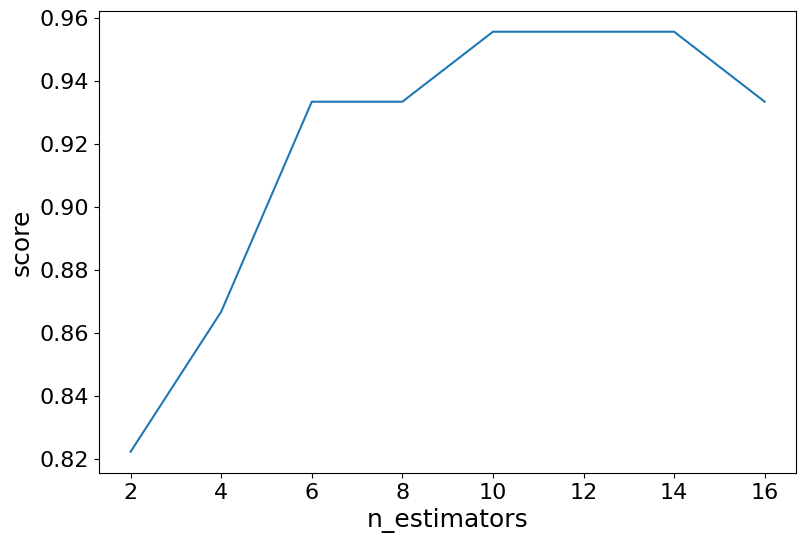

In [ ]:
data = datasets.load_wine()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 22)

estimator_range = [2,4,6,8,10,12,14,16]

models = []
scores = []

for n_estimators in estimator_range:
    
    # create bagging classifier
    clf = BaggingClassifier(n_estimators = n_estimators, random_state = 22)
    
    # fit the model
    clf.fit(X_train, y_train)
    
    # append the model and score to their respective list
    models.append(clf)
    scores.append(accuracy_score(y_true = y_test, y_pred = clf.predict(X_test)))
    
# generate the plot of scores against number of estimators
plt.figure(figsize=(9,6))
plt.plot(estimator_range, scores)

# adjust labels and font (to make visable)
plt.xlabel("n_estimators", fontsize = 18)
plt.ylabel("score", fontsize = 18)
plt.tick_params(labelsize = 16)

# visualize plot
plt.show()

## Another Form of Evaluation
As bootstrapping chooses random subsets of observations to create classifiers, there are observations that are left out in the selection process. These "out-of-bag" observations can then be used to evaluate the model, similarly to that of a test set. Keep in mind, that out-of-bag estimation can overestimate error in binary classification problems and should only be used as a compliment to other metrics.

We saw in the last exercise that 12 estimators yielded the highest accuracy, so we will use that to create our model. This time setting the parameter oob_score to true to evaluate the model with out-of-bag score.

In [16]:
data = datasets.load_wine(as_frame = True)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 22)

oob_model = BaggingClassifier(n_estimators = 12, oob_score = True,random_state = 22)

oob_model.fit(X_train, y_train)

print(oob_model.oob_score_)

0.9398496240601504


Since the samples used in OOB and the test set are different, and the dataset is relatively small, there is a difference in the accuracy. It is rare that they would be exactly the same, again OOB should be used quick means for estimating error, but is not the only evaluation metric.

## Generating Decision Trees from Bagging Classifier
As was seen in the Decision Tree lesson, it is possible to graph the decision tree the model created. It is also possible to see the individual decision trees that went into the aggregated classifier. This helps us to gain a more intuitive understanding on how the bagging model arrives at its predictions.

Note: This is only functional with smaller datasets, where the trees are relatively shallow and narrow making them easy to visualize.

We will need to import plot_tree function from sklearn.tree. The different trees can be graphed by changing the estimator you wish to visualize.

[Text(0.4583333333333333, 0.875, 'proline <= 727.5\ngini = 0.611\nsamples = 82\nvalue = [54, 60, 19]'),
 Text(0.25, 0.625, 'flavanoids <= 1.335\ngini = 0.339\nsamples = 47\nvalue = [0, 58, 16]'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'hue <= 0.92\ngini = 0.266\nsamples = 15\nvalue = [0, 3, 16]'),
 Text(0.08333333333333333, 0.125, 'gini = 0.0\nsamples = 13\nvalue = [0, 0, 16]'),
 Text(0.25, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 3, 0]'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 32\nvalue = [0, 55, 0]'),
 Text(0.6666666666666666, 0.625, 'flavanoids <= 1.605\ngini = 0.159\nsamples = 35\nvalue = [54, 2, 3]'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'color_intensity <= 4.325\ngini = 0.375\nsamples = 3\nvalue = [0, 1, 3]'),
 Text(0.4166666666666667, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.5833333333333334, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 3]'),
 Text(0.8333333333333334, 0.375, 'magnesi

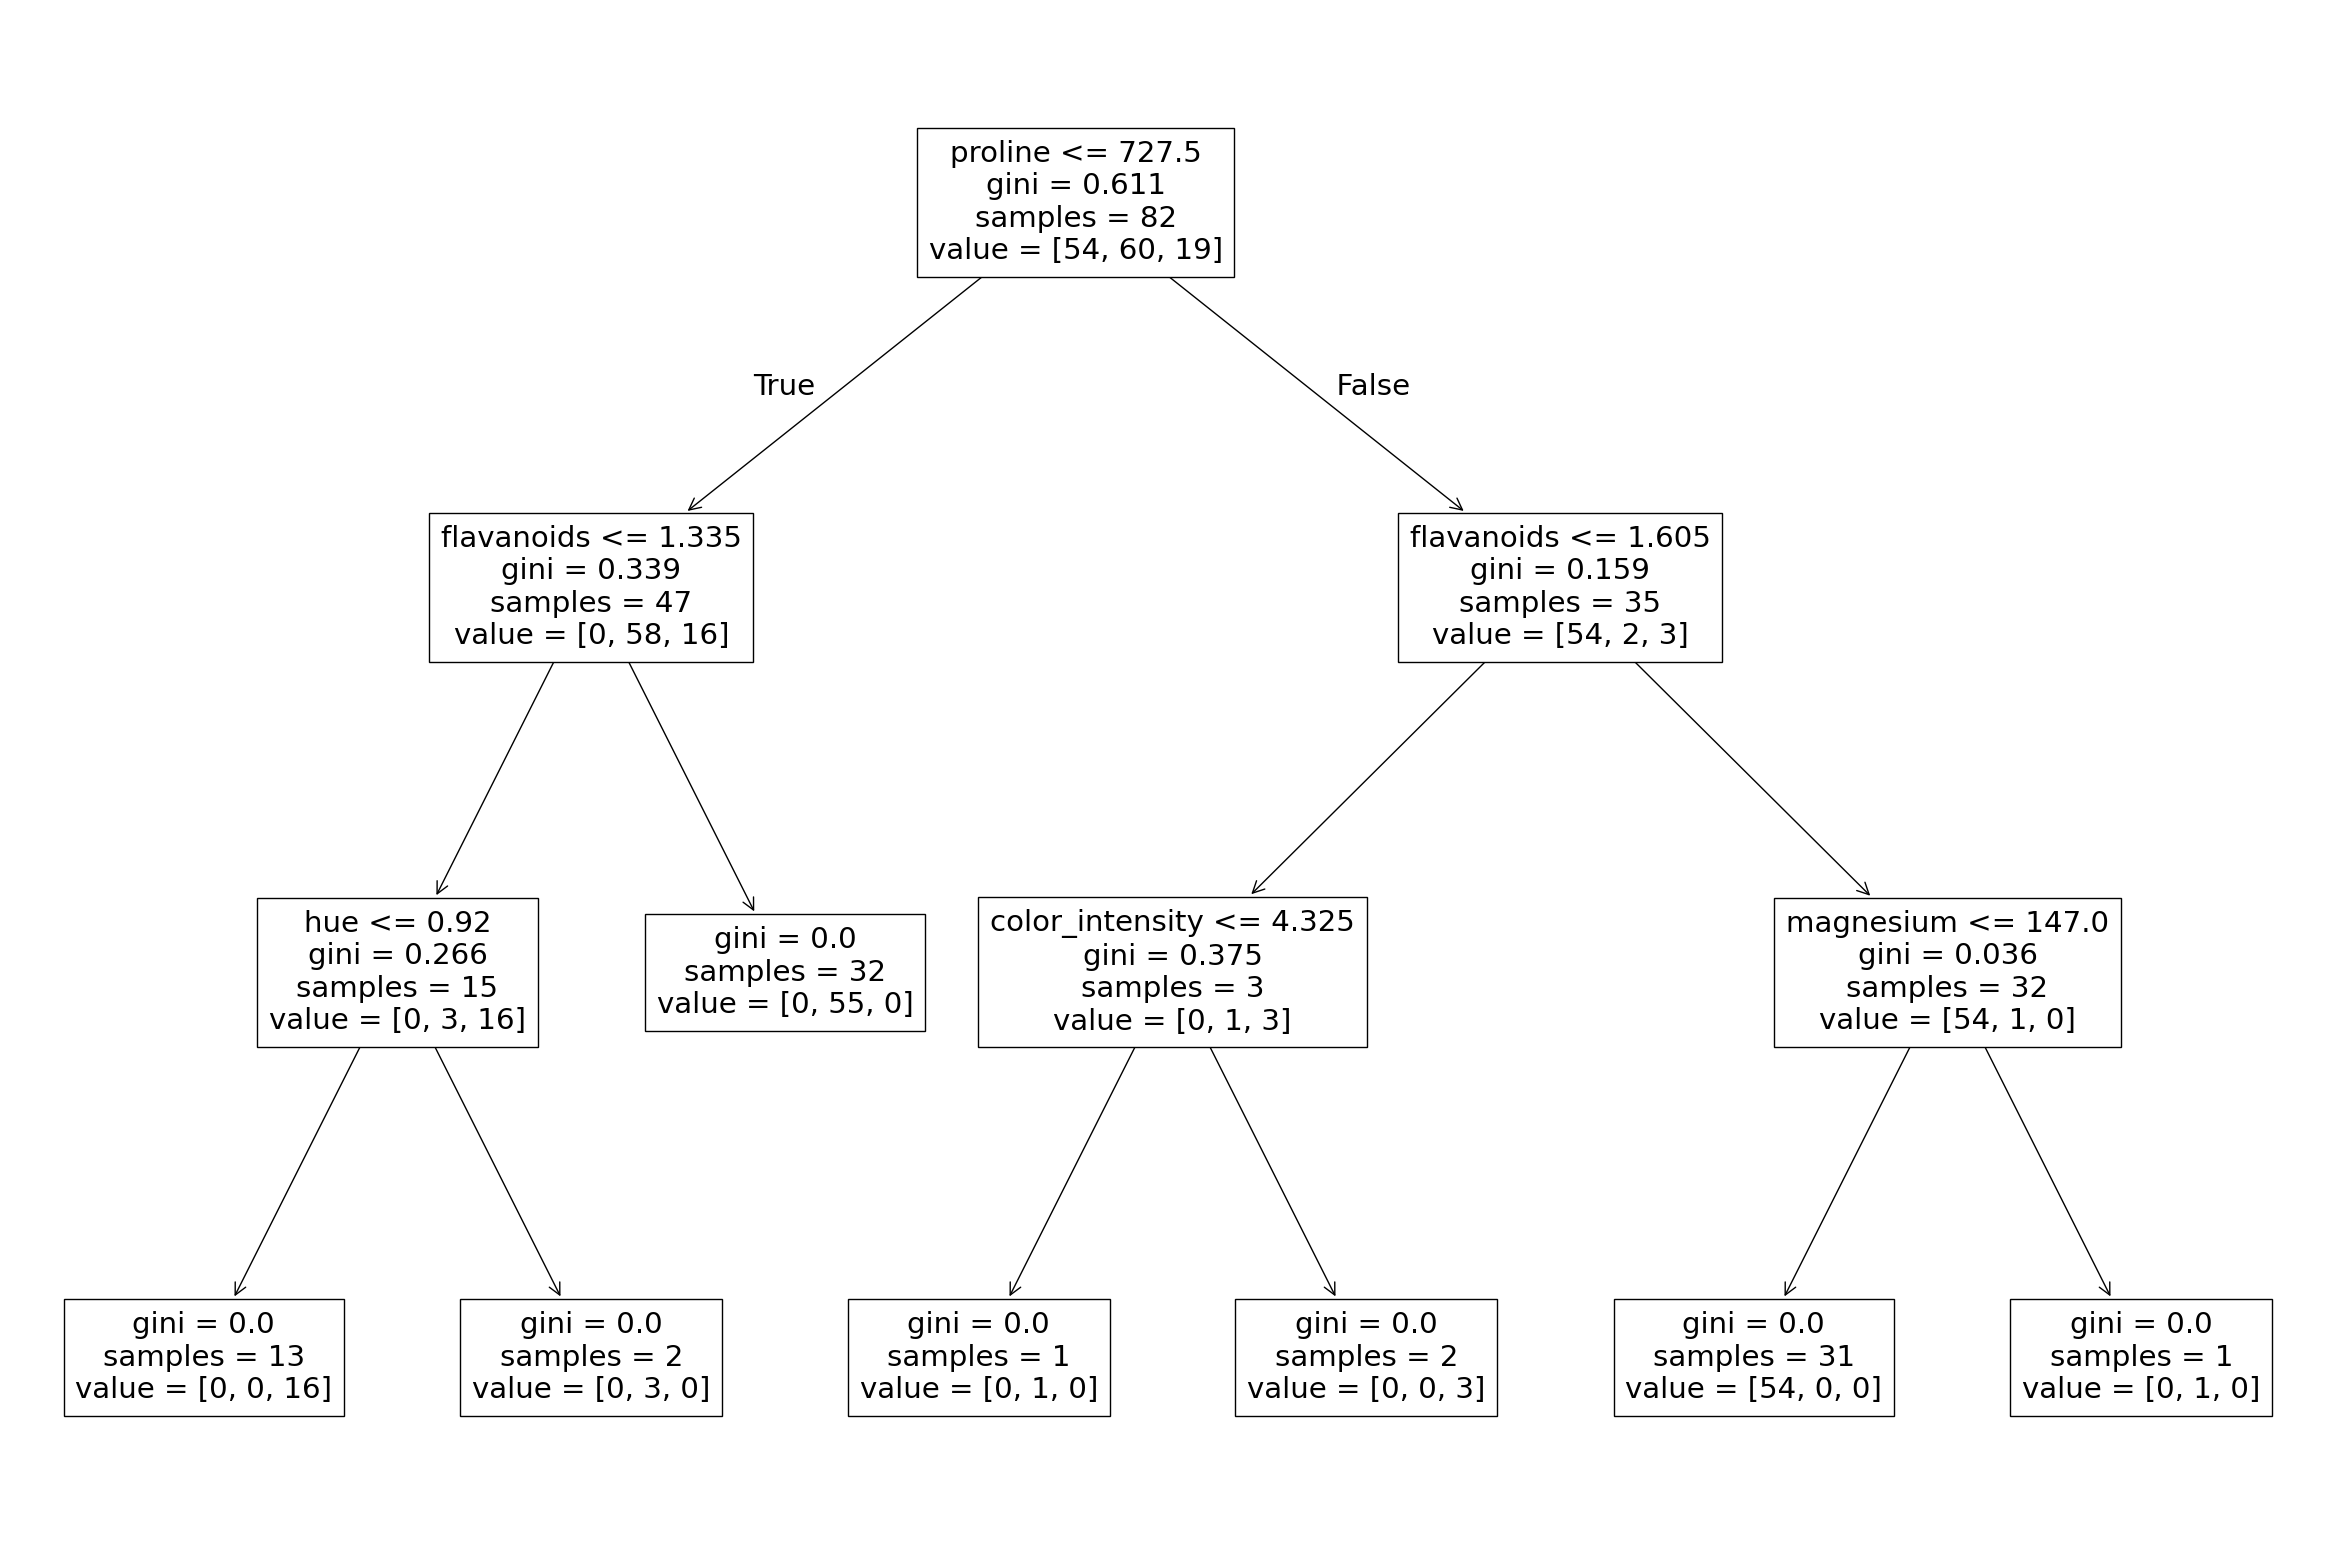

In [18]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 22)

clf = BaggingClassifier(n_estimators = 12, oob_score = True,random_state = 22)

clf.fit(X_train, y_train)

plt.figure(figsize=(30, 20))

plot_tree(clf.estimators_[0], feature_names = X.columns)